In [1]:
from PIL import Image
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications.vgg19 import preprocess_input

In [3]:
#Leitura dos dados extraídos do repositório
tab = pd.read_csv("./dados/train.csv", encoding='utf-8', low_memory=False)

In [4]:
len(tab)

1270

In [5]:
tab["image"] = "dados\\" + tab["image"]
tab.head(3)

,image,band_count,ohms,tolerance,watts,bands
0,dados\4-band\4B-100K-T5\4B-100K-T5-1.jpg,4,100000.0,0.05,0.25,brown black yellow gold
1,dados\4-band\4B-100K-T5\4B-100K-T5-10.jpg,4,100000.0,0.05,0.25,brown black yellow gold
2,dados\4-band\4B-100K-T5\4B-100K-T5-2.jpg,4,100000.0,0.05,0.25,brown black yellow gold


In [6]:
# Extrai o identificador do resistor (última pasta do caminho)
tab["resistor_id"] = tab["image"].str.extract(r'([^\\]+)\\[^\\]+$')

# Conta quantas imagens existem para cada resistor
contagem = tab["resistor_id"].value_counts()

# Identificadores com menos de 10 imagens
contagem.value_counts()

count
10    127
Name: count, dtype: int64

In [7]:
tab.resistor_id.value_counts()

resistor_id
4B-100K-T5    10
5B-1R5-T1     10
5B-2K4-T1     10
5B-2K2-T1     10
5B-2K-T1      10
              ..
4B-33K-T5     10
4B-330R-T5    10
4B-330K-T5    10
4B-2R7-T5     10
5B-9K1-T1     10
Name: count, Length: 127, dtype: int64

In [8]:
tab.count()

image          1270
band_count     1270
ohms           1270
tolerance      1270
watts          1270
bands          1270
resistor_id    1270
dtype: int64

In [9]:
l_encoder = LabelEncoder()

tab["label"] = l_encoder.fit_transform(tab["ohms"])

In [10]:
tab.head(3)

,image,band_count,ohms,tolerance,watts,bands,resistor_id,label
0,dados\4-band\4B-100K-T5\4B-100K-T5-1.jpg,4,100000.0,0.05,0.25,brown black yellow gold,4B-100K-T5,72
1,dados\4-band\4B-100K-T5\4B-100K-T5-10.jpg,4,100000.0,0.05,0.25,brown black yellow gold,4B-100K-T5,72
2,dados\4-band\4B-100K-T5\4B-100K-T5-2.jpg,4,100000.0,0.05,0.25,brown black yellow gold,4B-100K-T5,72


In [11]:
#Função para converter imagem para array
def convert_image(image_to_convert):
  
  image_to_convert = image_to_convert.convert('RGB')
  #redimenciona imagem
  image_to_convert = image_to_convert.resize((224,224))
  image = np.asarray(image_to_convert, dtype=np.float32)

  image = preprocess_input(image)
  return np.asarray(image_to_convert)

In [12]:
def select_images(tab):
    imagens = []
    labels = []
    for _, row in tab.iterrows():
        image = Image.open(os.path.normpath(row["image"]))
        image = convert_image(image)        
        imagens.append(image)
        labels.append(row["label"])        
    return np.array(imagens), np.array(labels)

In [13]:
imagens, labels = select_images(tab)


In [14]:
tab['Imagens'] = imagens

In [15]:
#Verificando quantidade de imagens para cada valor de resistência
tab.ohms.value_counts()

ohms
100000.0     20
270.0        20
2700.0       20
2200000.0    20
2.2          20
             ..
270000.0     10
12.0         10
12000.0      10
120000.0     10
9100.0       10
Name: count, Length: 89, dtype: int64

In [16]:
tab.ohms.nunique()

89

In [17]:
len(l_encoder.classes_)

89

In [18]:
#verificando se os tamnhos coincidem 
len(imagens), len(labels)

(1270, 1270)

In [19]:
#CALLBACKS
#São funções que podem ser passadas nos métodos do Keras para se integrar e auxiliar várias etapas do ciclo de vida do treinamento
#ModelCheckpoint: serve para salvar o modelo com uma certa frequência. Útil caso ocorra algum problema durante o processamento.
#https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint
#ReduceLROnPlateau: Reduz a taxa de aprendizado quando alguma métrica para de melhorar com o avanço do treinamento. Muitos modelos se beneficiam ao reduzer a taa de aprendizado em 20%

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping


In [20]:
#Definindo hiperparâmetros do modelo
batch_size   = 32
#Tamanho da imagem
input_shape  = (224, 224, 3)
#
random_state = 42
delta        = 1e-5
epoch        = 20

In [21]:
'''
path: onde será salvo o modelo
monitor: métrica a ser monitorada (acurácia)
verbose: (1) mostra na barra de progresso
save_best_only: Salvar somente o melhor modelo
mode: Queremos a máxima acurácia.
'''
###
path='resistors_transferlearning_weights.keras'
checkpoint = ModelCheckpoint(path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

In [22]:

#monitor: valor observado (acurácia)
#factor: fator de redução
#min-delta: limiar para medir o novo ótimo, para focar apenas em mudanças significativas
#patience: número de épocas sem evolução do modelo
#verbose = 1: mostra mensagens de atualização
lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, min_delta=delta, patience=5, verbose=1)
e_stopping = EarlyStopping(monitor="val_loss",
    min_delta=delta,
    patience=5,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,)
callbacks = [checkpoint, lr_reduce, e_stopping]

In [23]:
#Separa em treino e teste numa proporção de 70/30
(x_train, x_test, y_train, y_test) = train_test_split(imagens, labels, test_size=0.30, stratify=labels, random_state=random_state)

In [24]:
from tensorflow.keras.applications.vgg19 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15, # Rotação de 15 graus
    zoom_range=0.1, # zoom  de 10%
    width_shift_range=0.1, # modificação de 10% na largura
    height_shift_range=0.1, # modificação de 10% na altura
    horizontal_flip=False
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


train_generator = train_datagen.flow(
    x_train,
    y_train,
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow(
    x_test,
    y_test,
    batch_size=batch_size,
    shuffle=False
)


In [25]:
#transfer learning
#aproveita uma modelo treinado anteriormente
conv_base = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
conv_base.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#Retreinando parte da VGG19
conv_base.trainable = True
set_trainable = False
for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False
#

conv_base.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 9,439,232 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

In [27]:
#Instanciando modelo
    
num_classes = tab["label"].nunique()

model = models.Sequential([
    conv_base,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ ?                      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 9,439,232 (36.01 MB)

 Non-trainable params: 10,585,152 (40.38 MB)

In [28]:
model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=["accuracy"])

In [29]:
'''
history = model.fit(
    data_aug,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    epochs=epoch
)
''' 
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epoch,
    callbacks=callbacks
)

Epoch 1/20


c:\Users\luiz.altimari\Documents\IA\cnn-resistors\dl-env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.0085 - loss: 4.7182
Epoch 1: val_accuracy improved from -inf to 0.01312, saving model to resistors_transferlearning_weights.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 352s 12s/step - accuracy: 0.0086 - loss: 4.7167 - val_accuracy: 0.0131 - val_loss: 11.8974 - learning_rate: 0.0010
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.0235 - loss: 4.5490
Epoch 2: val_accuracy did not improve from 0.01312
28/28 ━━━━━━━━━━━━━━━━━━━━ 355s 13s/step - accuracy: 0.0234 - loss: 4.5500 - val_accuracy: 0.0079 - val_loss: 5.7578 - learning_rate: 0.0010
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.0087 - loss: 4.5266
Epoch 3: val_accuracy improved from 0.01312 to 0.01575, saving model to resistors_transferlearning_weights.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 354s 13s/step - accuracy: 0.0088 - loss: 4.5281 - val_accuracy: 0.0157 - val_loss: 5.4018 - learning_rate: 0.0010
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.0

In [30]:
hist = pd.DataFrame(history.history)
hist.to_csv("historico_treinamento-2.csv", index=False)

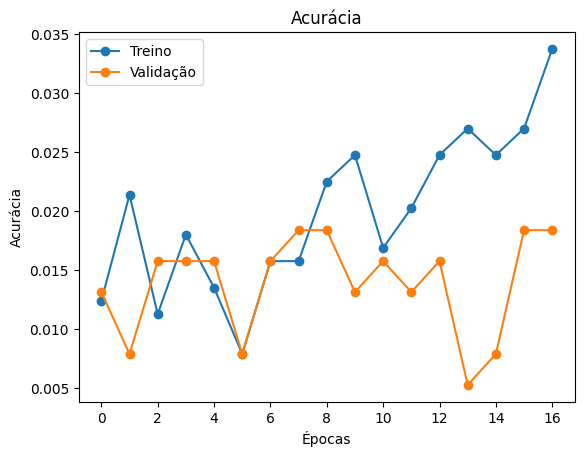

In [31]:

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title('Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(['Treino', 'Validação'])
plt.show()

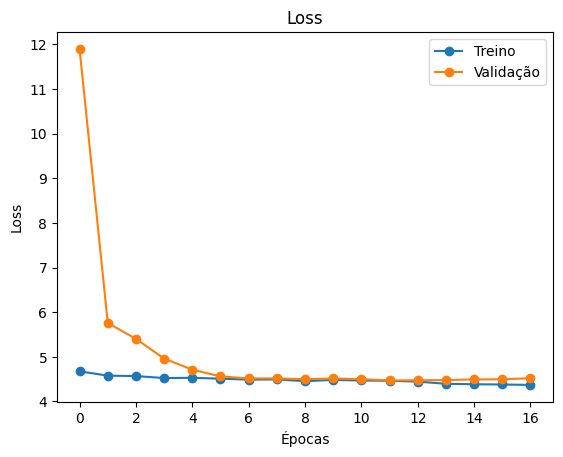

In [32]:
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Treino', 'Validação'])
plt.show()